In [1]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from collections import defaultdict
import itertools
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

In [2]:
class SparseHigherOrderNG(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, k_active=512, lambda3=1e-3,
                 n_triplets=200, random_hyperedges=True, 
                 beta1=0.9, beta2=0.999, eps=1e-8, approx=False):
        defaults = dict(lr=lr)
        super().__init__(params, defaults)
        self.k_active = k_active
        self.lambda3 = lambda3
        self.n_triplets = n_triplets
        self.random_hyperedges = random_hyperedges
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self._t = 0
        self.approx = approx

    def step(self, closure=None):
        self._t += 1

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if 'momentum' not in state:
                    state['momentum'] = torch.zeros_like(p.data)
                if 'fisher_ema' not in state:
                    state['fisher_ema'] = torch.zeros_like(p.data)

                state['momentum'] = (self.beta1 * state['momentum']
                                     + (1 - self.beta1) * p.grad)
                
                if self.approx:
                    state['fisher_ema'] = (self.beta2 * state['fisher_ema']
                                        + (1 - self.beta2) * p.grad.pow(2))

                #else:
                    
                m_hat = state['momentum'] / (1 - self.beta1 ** self._t)
                f_hat = (state['fisher_ema'] / (1 - self.beta2 ** self._t)).sqrt() + self.eps

                # Pure Adam update per parameter, no top-k
                p.data -= self.param_groups[0]['lr'] * m_hat / f_hat

        # Third-order correction only if lambda3 != 0
        if self.lambda3 != 0 and self._t > 100:
            # Collect full vectors for hyperedge computation
            params, grads = [], []
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue
                    params.append(p)
                    grads.append(p.grad.view(-1))

            g = torch.cat(grads)
            m_full = torch.cat([self.state[p]['momentum'].view(-1) for p in params])
            f_full = torch.cat([self.state[p]['fisher_ema'].view(-1) for p in params])

            m_hat = m_full / (1 - self.beta1 ** self._t)
            f_hat = f_full / (1 - self.beta2 ** self._t) + self.eps
            v_full = m_hat / f_hat

            # Top-k for hyperedge computation only
            k = min(self.k_active, g.numel())
            _, top_idx = torch.topk(m_hat.abs(), k=k)
            m_small = m_hat[top_idx]
            v_small = v_full[top_idx]
            k = m_small.shape[0]

            idx = torch.randint(0, k, (self.n_triplets, 3), device=g.device)
            i, j, kk = idx[:, 0], idx[:, 1], idx[:, 2]

            w = m_small[i] * m_small[j] * m_small[kk]

            c_small = torch.zeros_like(v_small)
            c_small.scatter_add_(0, i,  w * v_small[j]  * v_small[kk])
            c_small.scatter_add_(0, j,  w * v_small[i]  * v_small[kk])
            c_small.scatter_add_(0, kk, w * v_small[i]  * v_small[j])
            c_small = c_small / self.n_triplets

            correction = torch.zeros_like(m_full)
            correction[top_idx] = c_small

            #print(f"t={self._t} correction max: {correction.abs().max().item():.3e}")
            
            
            offset = 0
            for p in params:
                numel = p.numel()
                p.data -= self.param_groups[0]['lr'] * self.lambda3 * correction[offset:offset + numel].view_as(p)
                offset += numel

        return None

In [3]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

# Exact Fisher - per sample gradients

In [ ]:
import tqdm
from torch.func import grad, vmap, functional_call

BATCH_SIZE = 32


adam_loss = []

for i in tqdm.tqdm(range(3)):

    run_adam_loss = []
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    full_dataset = datasets.MNIST('.', train=True, download=True, transform=transforms.ToTensor())
    all_x = torch.stack([full_dataset[i][0] for i in range(len(full_dataset))]).to(device)
    all_y = torch.tensor([full_dataset[i][1] for i in range(len(full_dataset))]).to(device)

    test_loader = DataLoader(
        datasets.MNIST('.', train=False, download=True,
                        transform=transforms.ToTensor()),
        batch_size=BATCH_SIZE, shuffle=False)
    
    model = MLP().to(device)

    def loss_per_sample(params, buffers, x, y):
        out = functional_call(model, (params, buffers), x.unsqueeze(0))
        return nn.CrossEntropyLoss()(out, y.unsqueeze(0))
    
    optimizer = SparseHigherOrderNG(model.parameters(), lr=1e-3, 
                                    k_active=128,
                                    lambda3=1e-4, 
                                    n_triplets=64, 
                                    random_hyperedges=True)

    criterion = nn.CrossEntropyLoss()

    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())

    
    for epoch in range(20):
        idx = torch.randperm(len(all_x))
        for start in range(0, len(all_x), BATCH_SIZE):
            x = all_x[idx[start:start+BATCH_SIZE]]
            y = all_y[idx[start:start+BATCH_SIZE]]

            # Compute per-sample gradients
            chunk_size = 4
            all_grads = {name: [] for name in params}
            
            
            for chunk_start in range(0, x.shape[0], chunk_size):
                xc = x[chunk_start:chunk_start+chunk_size]
                yc = y[chunk_start:chunk_start+chunk_size]
                chunk_grads = vmap(grad(loss_per_sample), in_dims=(None, None, 0, 0))(
                    params, buffers, xc, yc
                )
                for name, g in chunk_grads.items():
                    all_grads[name].append(g.detach().cpu())
            
            per_sample_grads = {name: torch.cat(gs).to(device) 
                    for name, gs in all_grads.items()}
            
            # Assign exact Fisher diagonal and mean gradient to p.grad
            optimizer.zero_grad()
            
            for name, p in model.named_parameters():
                g = per_sample_grads[name]
                p.grad = g.mean(0)
                state = optimizer.state[p]
                if 'fisher_ema' not in state:
                    state['fisher_ema'] = (g ** 2).mean(0)
                else:
                    state['fisher_ema'] = (
                        optimizer.beta2 * state['fisher_ema']
                        + (1 - optimizer.beta2) * (g ** 2).mean(0)
                    )
            optimizer.step()

        #print(f"Epoch {epoch}, loss {loss.item():.4f}")
        
        model.eval()
        test_loss = 0
        correct = 0
                
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                test_loss += loss.item()

                preds = out.argmax(dim=1)
                correct += (preds == y).sum().item()

        test_loss /= len(test_loader)
        accuracy = correct / len(test_loader.dataset)
        run_adam_loss.append(test_loss)

        model.train()

    adam_loss.append(run_adam_loss)

adam_loss = np.array(adam_loss)
#np.save("adam.npy", adam_loss)
#np.save("adam_approx.npy", adam_loss)
np.save("higher_order_exact.npy", adam_loss)


  0%|          | 0/3 [00:00<?, ?it/s]

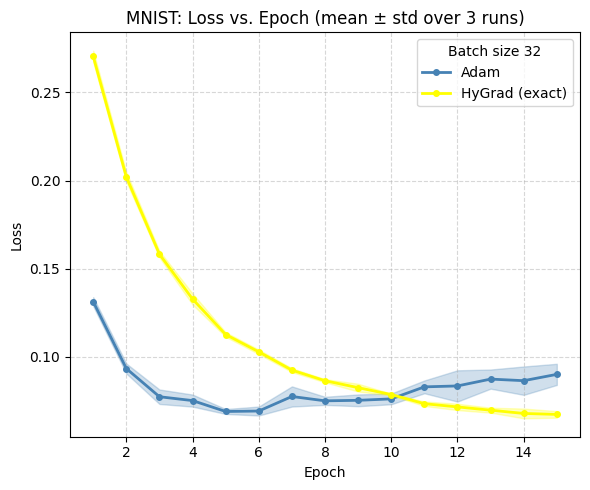

In [10]:
import matplotlib.pyplot as plt

loss_ad = np.load('adam.npy')
#loss_ad_approx = np.load('adam_approx.npy')
loss_hygrad = np.load('higher_order_exact.npy')

#print(loss_ad)

epochs = np.arange(1, 16)  # Epochs 1–15
mean_ad = loss_ad.mean(axis=0)   # Shape: (15,)
std_ad  = loss_ad.std(axis=0)    # Shape: (15,)
#mean_ad_approx = loss_ad_approx.mean(axis=0)   # Shape: (15,)
#std_ad_approx  = loss_ad_approx.std(axis=0)    # Shape: (15,)
mean_hygrad = loss_hygrad.mean(axis=0)   # Shape: (15,)
std_hygrad  = loss_hygrad.std(axis=0)    # Shape: (15,)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(epochs, mean_ad, color="steelblue", linewidth=2, marker="o", markersize=4, label="Adam")
ax.fill_between(epochs, mean_ad - std_ad, mean_ad + std_ad, alpha=0.25, color="steelblue")
#ax.plot(epochs, mean_ad_approx, color="indianred", linewidth=2, marker="o", markersize=4, label="Adam Approx")
#ax.fill_between(epochs, mean_ad_approx - std_ad_approx, mean_ad_approx + std_ad_approx, alpha=0.25, color="indianred")
ax.plot(epochs, mean_hygrad, color="yellow", linewidth=2, marker="o", markersize=4, label="HyGrad (exact)")
ax.fill_between(epochs, mean_hygrad - std_hygrad, mean_hygrad + std_hygrad, alpha=0.25, color="yellow")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("MNIST: Loss vs. Epoch (mean ± std over 3 runs)")
ax.legend(title="Batch size 32")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=250)
plt.show()

# Standard Adam

In [7]:
import tqdm

adam_loss = []

for i in tqdm.tqdm(range(3)):

    run_adam_loss = []
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    full_dataset = datasets.MNIST('.', train=True, download=True, transform=transforms.ToTensor())
    all_x = torch.stack([full_dataset[i][0] for i in range(len(full_dataset))]).to(device)
    all_y = torch.tensor([full_dataset[i][1] for i in range(len(full_dataset))]).to(device)

    test_loader = DataLoader(
        datasets.MNIST('.', train=False, download=True,
                        transform=transforms.ToTensor()),
        batch_size=BATCH_SIZE, shuffle=False)

    model = MLP().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    criterion = nn.CrossEntropyLoss()

    for epoch in range(15):
        idx = torch.randperm(len(all_x))
        for start in range(0, len(all_x), BATCH_SIZE):
            x = all_x[idx[start:start+BATCH_SIZE]]
            y = all_y[idx[start:start+BATCH_SIZE]]
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        model.eval()
        test_loss = 0
        correct = 0
                
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                test_loss += loss.item()

                preds = out.argmax(dim=1)
                correct += (preds == y).sum().item()

        test_loss /= len(test_loader)
        accuracy = correct / len(test_loader.dataset)
        run_adam_loss.append(test_loss)

        model.train()

    adam_loss.append(run_adam_loss)

adam_loss = np.array(adam_loss)
np.save("adam.npy", adam_loss)
#np.save("adam_approx.npy", adam_loss)
#np.save("higher_order.npy", adam_loss)

100%|██████████| 3/3 [04:18<00:00, 86.11s/it]
